# Лабораторная работа №3. Вариант №18. Задание 4

4. Для следующих 6-ти строчек из массива выполнить интерполяцию с помощью **второй** интерполяционной формулы Ньютона (`h = 0.1`), построить график.


Подключение библиотек


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

Получение данных из файла. Заносим в переменную `headers` заголовки столбцов, а в `values` соответственно значения.


In [2]:
clear_data = np.loadtxt(
    "18_Архангельск.csv", delimiter=",", dtype=str, encoding="utf-8-sig"
)

headers = clear_data[0]
values = clear_data[1:].astype(float)

headers

array(['Год', 'янв', 'фев', 'мар', 'апр', 'май', 'июн', 'июл', 'авг',
       'сен', 'окт', 'ноя', 'дек', 'средняя'], dtype='<U7')

Функция для отбора данных из таблицы данных.

Нам нужно взять информацию из столбцов, где нет значения «999.9». Поэтому мы сделаем так, чтобы строки с этим значением не учитывались.


In [3]:
def clear_cols(
    array: np.ndarray, col: int | list[int] = None, error: float | int | list = 999.9
) -> list[float] | np.ndarray:
    if col is None:
        col = list(range(array.shape[1]))
    elif isinstance(col, int):
        col = [col]

    if isinstance(error, (float, int)):
        error = [error]

    mask = np.ones(len(array), dtype=bool)
    for c in col:
        for err in error:
            mask &= array[:, c] != err

    result = array[mask][:, col].T

    if len(col) == 1:
        return result[0]
    else:
        return result

## 2-я интерполяционная формула Ньютона (назад)

$$q = \frac{x - x_n}{n} < 0$$
$$N_{n}^{II}(x) = y_n + q \Delta y_{n-1} + \frac{q(q+1)}{2!} \Delta^2 y_{n-2} + \dots + \frac{q(q+1)\dots(q+n-1)}{n!} \Delta^n y_0$$


In [4]:
def delta_y_n(data: list[float] | np.ndarray, k: int, n: int = 0) -> float:
    if len(data) <= k:
        raise ValueError(
            f"Переменная k должна быть меньше длины списка: {k} >= {len(data)}"
        )

    if len(data) - k - 1 < n:
        raise ValueError(
            f"На строке {k=} не может быть больше {len(data) - k} элементов"
        )

    if k == 0:
        return data[n]

    result = 0
    b = 1.0
    for i in range(n, k + n + 1):
        result += (-1) ** (k - i + n) * b * data[i]
        b *= (k - i + n) / (i - n + 1)

    return result


def newton_interpolation_second(
    x: float, x_data: list[float] | np.ndarray, y_data: list[float] | np.ndarray
) -> float:
    h = x_data[1] - x_data[0]
    if not all(
        abs(x_data[i + 1] - x_data[i] - h) < 1e-10 for i in range(len(x_data) - 1)
    ):
        raise ValueError("Шаг по оси h различается")

    n = len(y_data)
    q = (x - x_data[-1]) / h
    fact = 1.0
    N = y_data[-1]
    prod = 1

    for i in range(1, n):
        prod *= q + i - 1
        fact *= i
        N += delta_y_n(y_data, i, n - i - 1) * prod / fact

    return N

In [5]:
delta_y_n([1, 2, 3, 4, 5], 0, 1)

2

Получаем очищенные данные из необходимых столбцов. Пусть это будет _год_ и _январь_.


In [6]:
cols = (0, 1)

x_data, y_data = clear_cols(values, cols)

start = 0
end = start + 6

y_data, x_data = y_data[start:end], x_data[start:end]

print(f"{x_data=}")
print(f"{y_data=}")

x_data=array([1814., 1815., 1816., 1817., 1818., 1819.])
y_data=array([-24.6, -11.7,  -8.2,  -8.7, -10.1,  -8.3])


Построение графика


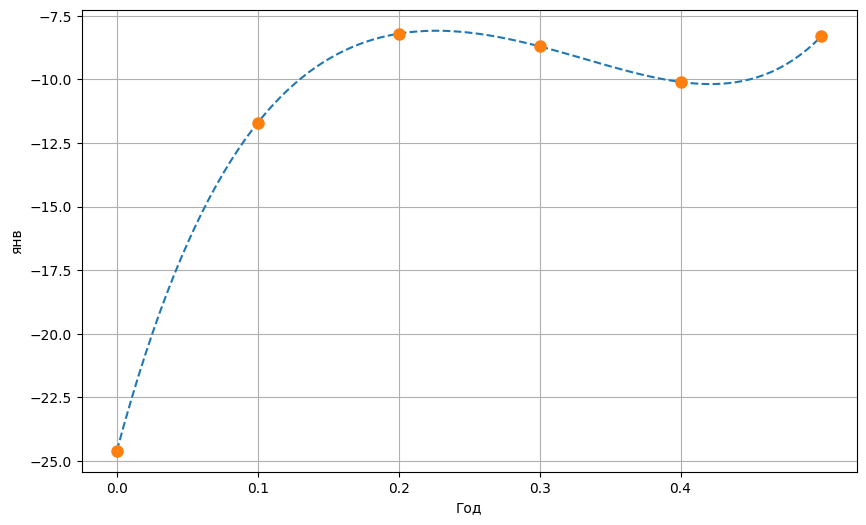

In [10]:
x_smooth = np.linspace(min(x_data), max(x_data), 100)
y_smooth = [newton_interpolation_second(x, x_data, y_data) for x in x_smooth]

plt.figure(figsize=(10, 6))
ax = plt.gca()
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, color="black")

plt.plot(x_smooth, y_smooth, "--")
plt.plot(x_data, y_data, "o", markersize=8)
plt.xticks(np.arange(x_data[0], x_data[-1], 1), [i / 10 for i in range(x_data.shape[0]-1)])

plt.xlabel(headers[cols[0]])
plt.ylabel(headers[cols[1]])
plt.grid(True)
plt.show()